## import libraries

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Load your local dataset

In [4]:
df = pd.read_csv('Titanic-Dataset.csv')

### 1.Clean Data

In [7]:
# Load your local dataset
df = pd.read_csv('Titanic-Dataset.csv')

# 1. Fill missing Age with the mean
df['Age'] = df['Age'].fillna(df['Age'].mean())

# 2. Drop irrelevant columns (Cabin is mostly missing, Name/Ticket are unique strings)
df.drop(columns=['Cabin', 'Name', 'Ticket'], inplace=True)

# 3. Create 'FamilySize' (SibSp + Parch)
df['FamilySize'] = df['SibSp'] + df['Parch']

### 2.Analysis Question

In [9]:
# A. Survival rate by Age Group
bins = [0, 12, 18, 60, 100]
labels = ['Child', 'Teenager', 'Adult', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
age_survival = df.groupby('AgeGroup',observed=False)['Survived'].mean()

# B. Survival rate by Embarkation Port (C = Cherbourg, Q = Queenstown, S = Southampton)
port_survival = df.groupby('Embarked')['Survived'].mean()

# C. Survival rate by Family size
family_survival = df.groupby('FamilySize')['Survived'].mean()

print("--- Survival Insights ---")
print(f"By Age Group:\n{age_survival}\n")
print(f"By Port:\n{port_survival}\n")
print(f"By Family Size:\n{family_survival}")

--- Survival Insights ---
By Age Group:
AgeGroup
Child       0.579710
Teenager    0.428571
Adult       0.365753
Senior      0.227273
Name: Survived, dtype: float64

By Port:
Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

By Family Size:
FamilySize
0     0.303538
1     0.552795
2     0.578431
3     0.724138
4     0.200000
5     0.136364
6     0.333333
7     0.000000
10    0.000000
Name: Survived, dtype: float64


### 3.Visualiuzations:

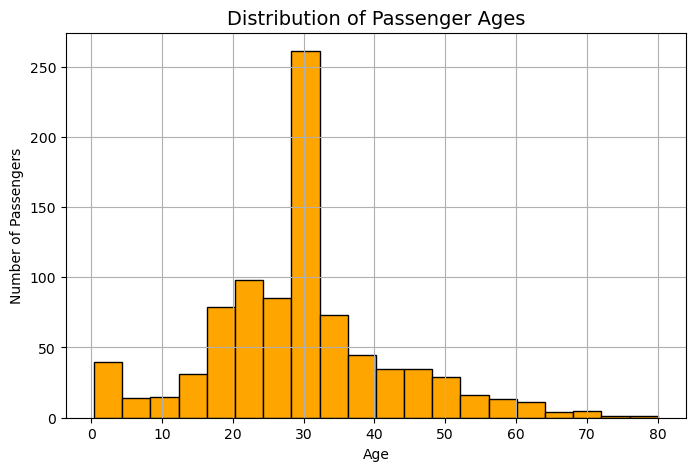

In [20]:
#Age Distribution (Histogram)
plt.figure(figsize=(8, 5))

plt.hist(df['Age'],bins=20,color='orange',edgecolor='black')

plt.title('Distribution of Passenger Ages', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Number of Passengers')

plt.grid(True)
plt.show()

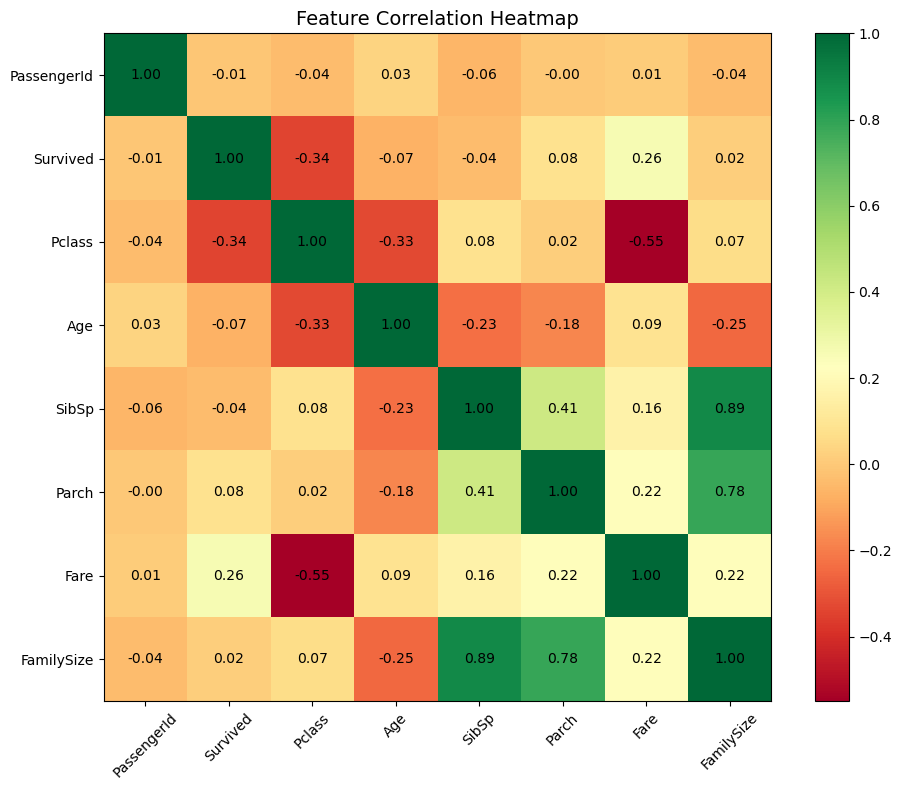

In [23]:
#Heatmap of correlations
import matplotlib.pyplot as plt
import numpy as np

# Select numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Correlation matrix
corr = numeric_df.corr()

# Heatmap Figure
plt.figure(figsize=(10, 8))

# Heatmap
im = plt.imshow(corr,cmap='RdYlGn',interpolation='nearest')

# Color bar
plt.colorbar(im)

# Axis labels
plt.xticks(range(len(corr.columns)),corr.columns,rotation=45)

plt.yticks(range(len(corr.columns)),corr.columns)

# Correlation values inside boxes
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j,i,f"{corr.iloc[i, j]:.2f}",ha='center',va='center',color='black')

# Title
plt.title('Feature Correlation Heatmap', fontsize=14)

plt.tight_layout()
plt.show()

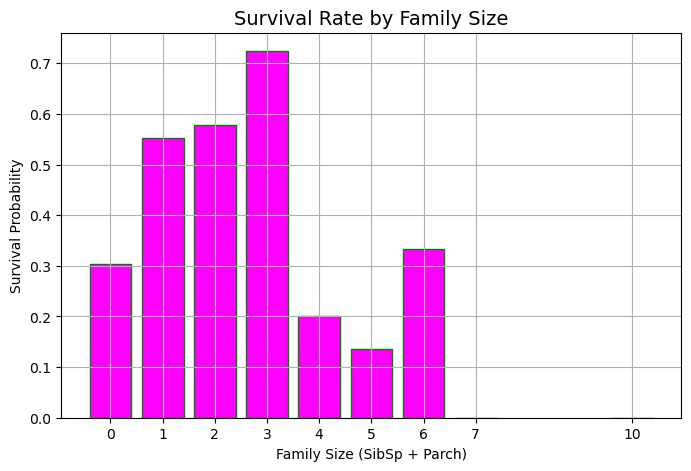

In [29]:
#Survival by Family Size Bar Plot
import matplotlib.pyplot as plt

# Bar Plot
plt.figure(figsize=(8, 5))

plt.bar(family_survival.index,family_survival.values,color='magenta',edgecolor='gree')

plt.title('Survival Rate by Family Size', fontsize=14)
plt.xlabel('Family Size (SibSp + Parch)')
plt.ylabel('Survival Probability')

plt.xticks(family_survival.index)

plt.grid(True)
plt.show()